# CLIP Fine-Tuned Model Production Validation

This notebook validates `checkpoints/best_clip_model.pt` on `arch-datasets` for production readiness:
- class-balanced benchmark sampling
- semantic classification quality
- threshold tuning for abstain/reject behavior
- hallucination-style tests (OOD/random/noise)
- deployment recommendation summary

In [18]:
from pathlib import Path
import random
import warnings

import clip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageFile
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [19]:
ROOT = Path(".").resolve()
DATASET_ROOT = ROOT / "arch-datasets"
CHECKPOINT_PATH = ROOT / "checkpoints" / "best_clip_model.pt"

assert DATASET_ROOT.exists(), f"Dataset folder not found: {DATASET_ROOT}"
assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"

print("Dataset:", DATASET_ROOT)
print("Checkpoint:", CHECKPOINT_PATH)

Dataset: D:\dev\visquery\fine-tune\arch-datasets
Checkpoint: D:\dev\visquery\fine-tune\checkpoints\best_clip_model.pt


In [20]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def build_label_image_table(dataset_root: Path) -> pd.DataFrame:
    rows = []
    for class_dir in sorted([d for d in dataset_root.iterdir() if d.is_dir()]):
        label = class_dir.name
        for img_path in class_dir.rglob("*"):
            if img_path.is_file() and img_path.suffix.lower() in IMG_EXT:
                rows.append({"label": label, "image_path": str(img_path)})
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No images discovered in arch-datasets.")
    return df

full_df = build_label_image_table(DATASET_ROOT)
class_counts = full_df.groupby("label").size().sort_values(ascending=False)
print(f"Total images: {len(full_df):,}")
print(f"Total classes: {class_counts.shape[0]}")
class_counts.head(10)

Total images: 5,319
Total classes: 25


label
Achaemenid architecture             323
American Foursquare architecture    303
Colonial architecture               303
Queen Anne architecture             295
Tudor Revival architecture          293
Beaux-Arts architecture             233
Palladian architecture              230
Georgian architecture               227
Bauhaus architecture                223
Gothic architecture                 222
dtype: int64

In [21]:
# Benchmark sampling: balanced random subset per class.
SAMPLES_PER_CLASS = 20

def sample_benchmark(df: pd.DataFrame, samples_per_class: int = 20, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    sampled = []
    for label, g in df.groupby("label"):
        n = min(samples_per_class, len(g))
        idx = rng.choice(g.index.values, size=n, replace=False)
        sampled.append(df.loc[idx])
    out = pd.concat(sampled, ignore_index=True)
    return out.sample(frac=1, random_state=seed).reset_index(drop=True)

benchmark_df = sample_benchmark(full_df, samples_per_class=SAMPLES_PER_CLASS, seed=SEED)
print(f"Benchmark rows: {len(benchmark_df):,}")
benchmark_df.groupby("label").size().describe()

Benchmark rows: 500


count    25.0
mean     20.0
std       0.0
min      20.0
25%      20.0
50%      20.0
75%      20.0
max      20.0
dtype: float64

In [22]:
model, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
state_dict = checkpoint.get("model_state_dict", checkpoint)

# Support both normal and DataParallel checkpoints.
clean_state_dict = {
    (k.replace("module.", "", 1) if k.startswith("module.") else k): v
    for k, v in state_dict.items()
}

missing_keys, unexpected_keys = model.load_state_dict(clean_state_dict, strict=False)
model.eval()

print("Checkpoint epoch:", checkpoint.get("epoch", "n/a"))
print("Checkpoint best_accuracy:", checkpoint.get("best_accuracy", "n/a"))
print("Missing keys:", len(missing_keys), "Unexpected keys:", len(unexpected_keys))

Checkpoint epoch: 12
Checkpoint best_accuracy: 0.8213166144200627
Missing keys: 0 Unexpected keys: 0


In [23]:
labels = sorted(full_df["label"].unique().tolist())
text_prompts = [f"a photo of {label}" for label in labels]

with torch.no_grad():
    text_tokens = clip.tokenize(text_prompts).to(DEVICE)
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

label_to_idx = {l: i for i, l in enumerate(labels)}
idx_to_label = {i: l for l, i in label_to_idx.items()}
print(f"Built text embeddings for {len(labels)} labels.")

Built text embeddings for 25 labels.


In [24]:
def encode_image(image_path: str) -> torch.Tensor:
    img = Image.open(image_path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        image_features = model.encode_image(x)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    return image_features

def predict_single(image_path: str):
    image_features = encode_image(image_path)
    with torch.no_grad():
        logits = 100.0 * image_features @ text_features.T
        probs = logits.softmax(dim=-1).squeeze(0).cpu().numpy()
    top_idx = int(np.argmax(probs))
    return idx_to_label[top_idx], float(probs[top_idx]), probs

In [25]:
records = []
for row in benchmark_df.itertuples(index=False):
    pred_label, pred_conf, probs = predict_single(row.image_path)
    records.append(
        {
            "image_path": row.image_path,
            "true_label": row.label,
            "pred_label": pred_label,
            "conf": pred_conf,
            "correct": int(pred_label == row.label),
        }
    )

pred_df = pd.DataFrame(records)
acc = accuracy_score(pred_df["true_label"], pred_df["pred_label"])
macro_f1 = f1_score(pred_df["true_label"], pred_df["pred_label"], average="macro")

print(f"Benchmark accuracy: {acc:.4f}")
print(f"Benchmark macro F1: {macro_f1:.4f}")
pred_df.head()

Benchmark accuracy: 0.8740
Benchmark macro F1: 0.8751


,image_path,true_label,pred_label,conf,correct
0,D:\dev\visquery\fine-tune\arch-datasets\Novelt...,Novelty architecture,Postmodern architecture,0.995605,0
1,D:\dev\visquery\fine-tune\arch-datasets\Ancien...,Ancient Egyptian architecture,Ancient Egyptian architecture,1.000000,1
2,D:\dev\visquery\fine-tune\arch-datasets\Novelt...,Novelty architecture,Novelty architecture,1.000000,1
3,D:\dev\visquery\fine-tune\arch-datasets\Bauhau...,Bauhaus architecture,Bauhaus architecture,1.000000,1
4,D:\dev\visquery\fine-tune\arch-datasets\Art No...,Art Nouveau architecture,Art Nouveau architecture,1.000000,1


In [26]:
print(classification_report(pred_df["true_label"], pred_df["pred_label"], zero_division=0))

                                  precision    recall  f1-score   support

         Achaemenid architecture       0.95      0.95      0.95        20
American Foursquare architecture       0.85      0.85      0.85        20
        American craftsman style       0.89      0.85      0.87        20
   Ancient Egyptian architecture       1.00      0.95      0.97        20
           Art Deco architecture       0.94      0.85      0.89        20
        Art Nouveau architecture       0.91      1.00      0.95        20
            Baroque architecture       0.95      1.00      0.98        20
            Bauhaus architecture       0.82      0.90      0.86        20
         Beaux-Arts architecture       0.73      0.80      0.76        20
          Byzantine architecture       0.94      0.85      0.89        20
     Chicago school architecture       1.00      0.90      0.95        20
           Colonial architecture       0.88      0.70      0.78        20
                Deconstructivism     

In [27]:
def evaluate_threshold(df: pd.DataFrame, threshold: float) -> dict:
    covered = df[df["conf"] >= threshold]
    coverage = len(covered) / len(df)
    if len(covered) == 0:
        return {"threshold": threshold, "coverage": 0.0, "accuracy": 0.0, "macro_f1": 0.0}
    a = accuracy_score(covered["true_label"], covered["pred_label"])
    f = f1_score(covered["true_label"], covered["pred_label"], average="macro")
    return {"threshold": threshold, "coverage": coverage, "accuracy": a, "macro_f1": f}

threshold_grid = np.linspace(0.10, 0.95, 18)
threshold_eval = pd.DataFrame([evaluate_threshold(pred_df, t) for t in threshold_grid])
threshold_eval.sort_values(["macro_f1", "accuracy"], ascending=False).head(10)

,threshold,coverage,accuracy,macro_f1
17,0.95,0.886,0.909707,0.909114
16,0.90,0.920,0.895652,0.895186
14,0.80,0.952,0.890756,0.890539
15,0.85,0.936,0.888889,0.888539
13,0.75,0.968,0.886364,0.886353
12,0.70,0.974,0.882957,0.883176
11,0.65,0.980,0.877551,0.878357
10,0.60,0.988,0.874494,0.875793
0,0.10,1.000,0.874000,0.875089
1,0.15,1.000,0.874000,0.875089


In [29]:
# Pick best threshold with minimum useful coverage constraint.
MIN_COVERAGE = 0.70
eligible = threshold_eval[threshold_eval["coverage"] >= MIN_COVERAGE].copy()

if len(eligible) == 0:
    best_row = threshold_eval.sort_values("macro_f1", ascending=False).iloc[0]
else:
    best_row = eligible.sort_values(["macro_f1", "accuracy"], ascending=False).iloc[0]

BEST_THRESHOLD = float(best_row["threshold"])
print("Recommended threshold:", round(BEST_THRESHOLD, 4))
best_row

Recommended threshold: 0.95


threshold    0.950000
coverage     0.886000
accuracy     0.909707
macro_f1     0.909114
Name: 17, dtype: float64

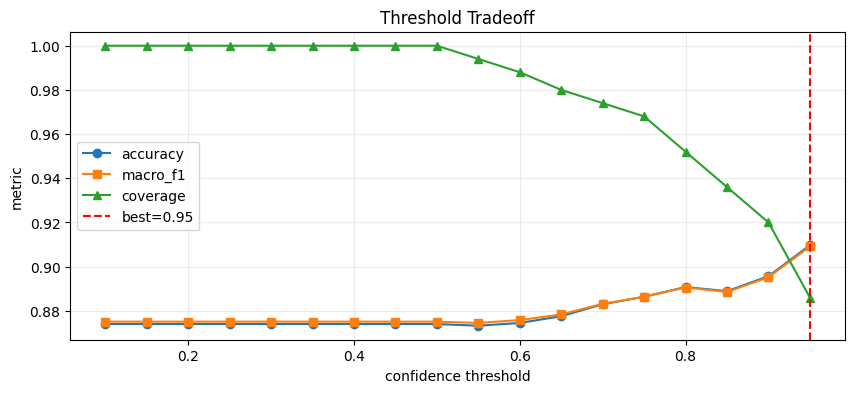

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(threshold_eval["threshold"], threshold_eval["accuracy"], marker="o", label="accuracy")
plt.plot(threshold_eval["threshold"], threshold_eval["macro_f1"], marker="s", label="macro_f1")
plt.plot(threshold_eval["threshold"], threshold_eval["coverage"], marker="^", label="coverage")
plt.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"best={BEST_THRESHOLD:.2f}")
plt.title("Threshold Tradeoff")
plt.xlabel("confidence threshold")
plt.ylabel("metric")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [31]:
# Hallucination-style tests: model should be low-confidence on unknown/noise inputs.
def random_noise_image(size=224):
    arr = np.random.randint(0, 256, (size, size, 3), dtype=np.uint8)
    return Image.fromarray(arr)

def evaluate_pil_image(img: Image.Image):
    x = preprocess(img.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        image_features = model.encode_image(x)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = 100.0 * image_features @ text_features.T
        probs = logits.softmax(dim=-1).squeeze(0).cpu().numpy()
    top_idx = int(np.argmax(probs))
    return idx_to_label[top_idx], float(probs[top_idx])

ood_pool = full_df.sample(n=min(100, len(full_df)), random_state=SEED)
ood_conf = []
for r in ood_pool.itertuples(index=False):
    pred_label, conf, _ = predict_single(r.image_path)
    if pred_label != r.label:
        ood_conf.append(conf)

noise_trials = 50
noise_conf = []
for _ in range(noise_trials):
    _, c = evaluate_pil_image(random_noise_image(224))
    noise_conf.append(c)

hall_df = pd.DataFrame(
    {
        "case": ["misclassified_in_domain", "random_noise"],
        "mean_top_conf": [np.mean(ood_conf) if ood_conf else np.nan, float(np.mean(noise_conf))],
        "p95_top_conf": [np.percentile(ood_conf, 95) if ood_conf else np.nan, float(np.percentile(noise_conf, 95))],
        "n": [len(ood_conf), len(noise_conf)],
    }
)
hall_df

,case,mean_top_conf,p95_top_conf,n
0,misclassified_in_domain,0.886796,1.000000,19
1,random_noise,0.640742,0.784448,50


In [32]:
# Production gate recommendation.
covered = pred_df[pred_df["conf"] >= BEST_THRESHOLD]
rejected = pred_df[pred_df["conf"] < BEST_THRESHOLD]

summary = pd.DataFrame(
    {
        "metric": [
            "benchmark_total",
            "coverage_at_best_threshold",
            "accuracy_at_best_threshold",
            "macro_f1_at_best_threshold",
            "rejection_rate",
            "noise_mean_top_conf",
            "noise_p95_top_conf",
        ],
        "value": [
            len(pred_df),
            len(covered) / len(pred_df),
            accuracy_score(covered["true_label"], covered["pred_label"]) if len(covered) else 0.0,
            f1_score(covered["true_label"], covered["pred_label"], average="macro") if len(covered) else 0.0,
            len(rejected) / len(pred_df),
            float(np.mean(noise_conf)),
            float(np.percentile(noise_conf, 95)),
        ],
    }
)

display(summary)
print(f"\nRecommended production threshold: {BEST_THRESHOLD:.3f}")
print("Guidance: reject predictions below threshold and route to fallback/manual review.")

,metric,value
0,benchmark_total,500.000000
1,coverage_at_best_threshold,0.886000
2,accuracy_at_best_threshold,0.909707
3,macro_f1_at_best_threshold,0.909114
4,rejection_rate,0.114000
5,noise_mean_top_conf,0.640742
6,noise_p95_top_conf,0.784448



Recommended production threshold: 0.950
Guidance: reject predictions below threshold and route to fallback/manual review.


## Real-World Semantic Validation (`test-data`)

Accuracy on class names is not the main target here. This section evaluates semantic text-to-image behavior with descriptive prompts and multimodal metrics.

In [42]:
import re
from PIL import ImageEnhance, ImageFilter

TEST_DATA_ROOT = ROOT / 'test-data'
assert TEST_DATA_ROOT.exists(), f'test-data folder not found: {TEST_DATA_ROOT}'

def clean_style_from_filename(path: Path) -> str:
    name = path.stem
    name = re.sub(r'ezgif.*$', '', name, flags=re.IGNORECASE)
    name = re.sub(r'[-_]+', ' ', name)
    name = re.sub(r'\b\d+x\d+\b', ' ', name, flags=re.IGNORECASE)
    name = re.sub(r'\d+$', ' ', name)
    name = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()
    name = name.replace('architecture', ' architecture')
    name = re.sub(r'\s+', ' ', name).strip().lower()
    if not name.endswith('architecture'):
        name = f'{name} architecture'
    return name

# Curated semantic prompts (3 per style). Gothic style includes your exact examples.
STYLE_PROMPTS = {
    'gothic architecture': [
        'a Gothic cathedral with pointed arches',
        'medieval European church architecture',
        'ornate stone cathedral with flying buttresses',
    ],
    'perpendicular gothic architecture': [
        'late medieval English Gothic church with strong vertical lines',
        'perpendicular Gothic cathedral facade with large traceried windows',
        'stone church architecture with rectilinear Gothic detailing',
    ],
    'byzantine architecture': [
        'church architecture with domes and rich mosaics',
        'eastern Roman religious architecture with centralized plans',
        'Byzantine basilica with rounded domes and ornate interiors',
    ],
    'romanesque architecture': [
        'massive stone church with rounded arches and thick walls',
        'medieval Romanesque abbey architecture',
        'fortress-like cathedral with small windows and arcades',
    ],
    'roman architecture': [
        'ancient Roman monument with arches and columns',
        'classical Roman civic architecture in stone',
        'imperial Roman building with vaults and symmetry',
    ],
    'renaissance architecture': [
        'symmetrical Renaissance palace facade with classical proportions',
        'Italian Renaissance urban architecture with pilasters',
        'humanist architecture inspired by classical antiquity',
    ],
    'baroque architecture': [
        'dramatic Baroque church facade with ornate decoration',
        'grand European Baroque architecture with movement and curves',
        'elaborate monumental architecture with rich sculptural detail',
    ],
    'neoclassical architecture': [
        'neoclassical building with clean columns and pediment',
        '18th century revival of classical Greek and Roman architecture',
        'formal symmetrical facade with restrained classical ornament',
    ],
    'greek revival architecture': [
        'Greek Revival building with temple front and columns',
        '19th century architecture inspired by ancient Greek temples',
        'white-columned civic architecture with pedimented porch',
    ],
    'palladian architecture': [
        'Palladian villa with strict symmetry and classical portico',
        'architecture inspired by Andrea Palladio and proportional geometry',
        'elegant neoclassical villa with central block and wings',
    ],
    'victorian architecture': [
        '19th century Victorian house with decorative trim',
        'ornate historic residential architecture with eclectic details',
        'multi-story facade with bay windows and rich ornamentation',
    ],
    'tudor architecture': [
        'Tudor style house with steep gables and timber framing',
        'English revival architecture with half-timbered facades',
        'residential architecture with tall chimneys and leaded windows',
    ],
    'norman architecture': [
        'Norman castle or church architecture with heavy masonry',
        'Romanesque Norman structure with round arches',
        'medieval fortress-like architecture in stone',
    ],
    'islamic architecture': [
        'Islamic architecture with geometric ornament and arches',
        'mosque architecture with domes, courtyards, and calligraphic details',
        'historic Middle Eastern architecture with patterned tilework',
    ],
    'persian architecture': [
        'Persian architecture with iwans and intricate tile decoration',
        'Iranian Islamic architecture with monumental vaulted spaces',
        'historic Persian building with muqarnas and geometric motifs',
    ],
    'ancient greek architecture': [
        'ancient Greek temple with Doric or Ionic columns',
        'classical Hellenic architecture in marble stone',
        'ruins of Greek architecture with colonnades and pediment',
    ],
    'ancient egyptian architecture': [
        'ancient Egyptian stone temple architecture',
        'monumental Egyptian architecture with pylons and hieroglyphic reliefs',
        'pharaonic architecture with massive columns and axial planning',
    ],
    'anglo saxon architecture': [
        'early medieval Anglo-Saxon church architecture',
        'pre-Norman English stone architecture with simple forms',
        'historic Anglo-Saxon masonry church with narrow openings',
    ],
    'carolingian architecture': [
        'Carolingian architecture with westwork and basilican forms',
        'early medieval Frankish palace or chapel architecture',
        'pre-Romanesque imperial church architecture in Europe',
    ],
    'mannerist architecture': [
        'Mannerist architecture with classical elements used in unusual composition',
        'late Renaissance architecture with tension and stylized ornament',
        'architectural facade with exaggerated proportions and decorative complexity',
    ],
}

STYLE_ALIASES = {
    'persian iranian architecture': 'persian architecture',
    'mannerism architecture': 'mannerist architecture',
}

test_images = sorted(
    [p for p in TEST_DATA_ROOT.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXT],
    key=lambda x: x.name.lower(),
)

rows = []
for idx, img in enumerate(test_images, start=1):
    raw = clean_style_from_filename(img)
    style_key = STYLE_ALIASES.get(raw, raw)
    prompts = STYLE_PROMPTS.get(style_key, [
        f'a building in {style_key}',
        f'{style_key} style architectural scene',
        f'historic {style_key} structure',
    ])
    rows.append({
        'order': idx,
        'file_name': img.name,
        'image_path': str(img),
        'style_key': style_key,
        'prompt_1': prompts[0],
        'prompt_2': prompts[1],
        'prompt_3': prompts[2],
    })

semantic_test_df = pd.DataFrame(rows)
display(semantic_test_df[['order','file_name','style_key','prompt_1']])
print('Order check: images are sorted alphabetically by file name for deterministic evaluation.')

,order,file_name,style_key,prompt_1
0,1,AncientEgyptianArchitecture.webp,ancient egyptian architecture,ancient Egyptian stone temple architecture
1,2,AncientGreekArchitecture.webp,ancient greek architecture,ancient Greek temple with Doric or Ionic columns
2,3,Anglo-SaxonArchitecture-ezgif.com-optiwebp.webp,anglo saxon architecture,early medieval Anglo-Saxon church architecture
3,4,Baroquearchitecture-ezgif.com-optiwebp-1-1.webp,baroque architecture,dramatic Baroque church facade with ornate dec...
4,5,ByzantineArchitecture-ezgif.com-optiwebp.webp,byzantine architecture,church architecture with domes and rich mosaics
5,6,CarolingianArchitecture-ezgif.com-optiwebp.webp,carolingian architecture,Carolingian architecture with westwork and bas...
6,7,GothicArchitecture-ezgif.com-optiwebp-1.webp,gothic architecture,a Gothic cathedral with pointed arches
7,8,GreekRevivalarchitecture-ezgif.com-optiwebp-1-...,greek revival architecture,Greek Revival building with temple front and c...
8,9,IslamicArchitecture-ezgif.com-optiwebp.webp,islamic architecture,Islamic architecture with geometric ornament a...
9,10,MannerismArchitecture-ezgif.com-jpg-to-webp-co...,mannerist architecture,Mannerist architecture with classical elements...


Order check: images are sorted alphabetically by file name for deterministic evaluation.


In [43]:
# Build prompt bank and embedding utilities for multimodal metrics.
# Use prompts from semantic_test_df so every evaluated style has positive prompts in the bank.
prompt_rows = []
for r in semantic_test_df.itertuples(index=False):
    prompt_rows.extend([
        {'style_key': r.style_key, 'prompt': r.prompt_1},
        {'style_key': r.style_key, 'prompt': r.prompt_2},
        {'style_key': r.style_key, 'prompt': r.prompt_3},
    ])

prompt_bank_df = pd.DataFrame(prompt_rows).drop_duplicates().reset_index(drop=True)
all_prompts = prompt_bank_df['prompt'].tolist()
prompt_style = prompt_bank_df['style_key'].tolist()

with torch.no_grad():
    tok = clip.tokenize(all_prompts).to(DEVICE)
    prompt_features = model.encode_text(tok)
    prompt_features = prompt_features / prompt_features.norm(dim=-1, keepdim=True)

def image_feature_from_pil(img: Image.Image) -> torch.Tensor:
    x = preprocess(img.convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat = model.encode_image(x)
        feat = feat / feat.norm(dim=-1, keepdim=True)
    return feat

def image_feature_from_path(path: str) -> torch.Tensor:
    img = Image.open(path).convert('RGB')
    return image_feature_from_pil(img)

def cosine_scores(image_feat: torch.Tensor):
    scores = (image_feat @ prompt_features.T).squeeze(0).detach().cpu().numpy()
    return scores

print('Prompt bank size:', len(all_prompts), 'Unique styles:', len(set(prompt_style)))


Prompt bank size: 60 Unique styles: 20


In [44]:
# 1) Retrieval Validation: prompt bank retrieval quality for expected style prompts.
retrieval_rows = []
for row in semantic_test_df.itertuples(index=False):
    feat = image_feature_from_path(row.image_path)
    scores = cosine_scores(feat)
    order = np.argsort(-scores)

    pos_idxs = [i for i, s in enumerate(prompt_style) if s == row.style_key]
    if len(pos_idxs) == 0:
        retrieval_rows.append({
            'file_name': row.file_name,
            'style_key': row.style_key,
            'best_positive_rank': np.nan,
            'positive_in_top1': 0,
            'positive_in_top3': 0,
            'positive_in_top5': 0,
            'mrr_component': 0.0,
            'missing_positive_prompts': 1,
        })
        continue

    ranked_positions = [int(np.where(order == i)[0][0]) + 1 for i in pos_idxs]
    best_rank = min(ranked_positions)

    retrieval_rows.append({
        'file_name': row.file_name,
        'style_key': row.style_key,
        'best_positive_rank': best_rank,
        'positive_in_top1': int(best_rank <= 1),
        'positive_in_top3': int(best_rank <= 3),
        'positive_in_top5': int(best_rank <= 5),
        'mrr_component': 1.0 / best_rank,
        'missing_positive_prompts': 0,
    })

retrieval_df = pd.DataFrame(retrieval_rows)
retrieval_summary = pd.DataFrame([
    {'metric': 'Recall@1', 'value': retrieval_df['positive_in_top1'].mean()},
    {'metric': 'Recall@3', 'value': retrieval_df['positive_in_top3'].mean()},
    {'metric': 'Recall@5', 'value': retrieval_df['positive_in_top5'].mean()},
    {'metric': 'MRR', 'value': retrieval_df['mrr_component'].mean()},
    {'metric': 'missing_positive_prompt_rows', 'value': int(retrieval_df['missing_positive_prompts'].sum())},
])
display(retrieval_summary)
display(retrieval_df[['file_name','style_key','best_positive_rank','missing_positive_prompts']].sort_values(['missing_positive_prompts','best_positive_rank'], ascending=[True, True]))


,metric,value
0,Recall@1,0.500000
1,Recall@3,0.700000
2,Recall@5,0.800000
3,MRR,0.639731
4,missing_positive_prompt_rows,0.000000


,file_name,style_key,best_positive_rank,missing_positive_prompts
0,AncientEgyptianArchitecture.webp,ancient egyptian architecture,1,0
3,Baroquearchitecture-ezgif.com-optiwebp-1-1.webp,baroque architecture,1,0
4,ByzantineArchitecture-ezgif.com-optiwebp.webp,byzantine architecture,1,0
6,GothicArchitecture-ezgif.com-optiwebp-1.webp,gothic architecture,1,0
7,GreekRevivalarchitecture-ezgif.com-optiwebp-1-...,greek revival architecture,1,0
8,IslamicArchitecture-ezgif.com-optiwebp.webp,islamic architecture,1,0
11,NormanArchitecture-ezgif.com-optiwebp.webp,norman architecture,1,0
12,Palladianarchitecture-ezgif.com-optiwebp.webp,palladian architecture,1,0
17,RomanesqueArchitecture-ezgif.com-optiwebp.webp,romanesque architecture,1,0
18,Tudorarchitecture-ezgif.com-optiwebp.webp,tudor architecture,1,0


In [45]:
# 2) Semantic Consistency Validation: agreement across paraphrase prompts per style.
consistency_rows = []
for row in semantic_test_df.itertuples(index=False):
    feat = image_feature_from_path(row.image_path)
    style_prompts = STYLE_PROMPTS[row.style_key]
    with torch.no_grad():
        tok = clip.tokenize(style_prompts).to(DEVICE)
        tfeat = model.encode_text(tok)
        tfeat = tfeat / tfeat.norm(dim=-1, keepdim=True)
    s = (feat @ tfeat.T).squeeze(0).detach().cpu().numpy()
    consistency_rows.append({
        'file_name': row.file_name,
        'style_key': row.style_key,
        'prompt_sim_mean': float(np.mean(s)),
        'prompt_sim_std': float(np.std(s)),
        'prompt_sim_min': float(np.min(s)),
        'prompt_sim_max': float(np.max(s)),
    })

consistency_df = pd.DataFrame(consistency_rows)
semantic_consistency_summary = pd.DataFrame([
    {'metric': 'mean_similarity', 'value': consistency_df['prompt_sim_mean'].mean()},
    {'metric': 'mean_prompt_std_lower_is_better', 'value': consistency_df['prompt_sim_std'].mean()},
    {'metric': 'p90_prompt_std', 'value': np.percentile(consistency_df['prompt_sim_std'], 90)},
])
display(semantic_consistency_summary)
display(consistency_df[['file_name','style_key','prompt_sim_mean','prompt_sim_std']].sort_values('prompt_sim_std'))

,metric,value
0,mean_similarity,0.189040
1,mean_prompt_std_lower_is_better,0.033791
2,p90_prompt_std,0.074762


,file_name,style_key,prompt_sim_mean,prompt_sim_std
8,IslamicArchitecture-ezgif.com-optiwebp.webp,islamic architecture,0.218384,0.006180
14,PersianIranianArchitecture-ezgif.com-optiwebp-...,persian architecture,0.215576,0.008194
13,PerpendicularGothicArchitecture-ezgif.com-jpg-...,perpendicular gothic architecture,0.232910,0.008560
10,NeoclassicalArchitecture-ezgif.com-optiwebp-10...,neoclassical architecture,0.083862,0.010681
19,VictorianArchitecture-ezgif.com-optiwebp.webp,victorian architecture,0.104065,0.013306
2,Anglo-SaxonArchitecture-ezgif.com-optiwebp.webp,anglo saxon architecture,0.212158,0.013657
9,MannerismArchitecture-ezgif.com-jpg-to-webp-co...,mannerist architecture,0.062256,0.016052
1,AncientGreekArchitecture.webp,ancient greek architecture,0.210205,0.018478
11,NormanArchitecture-ezgif.com-optiwebp.webp,norman architecture,0.258057,0.021439
0,AncientEgyptianArchitecture.webp,ancient egyptian architecture,0.267822,0.022156


In [46]:
# 3) Hard Negative Validation: margin between positive style prompts and confusing negatives.
HARD_NEGATIVES = {
    'gothic architecture': ['romanesque architecture', 'perpendicular gothic architecture'],
    'perpendicular gothic architecture': ['gothic architecture', 'romanesque architecture'],
    'romanesque architecture': ['gothic architecture', 'norman architecture'],
    'roman architecture': ['renaissance architecture', 'neoclassical architecture'],
    'renaissance architecture': ['baroque architecture', 'neoclassical architecture'],
    'baroque architecture': ['renaissance architecture', 'mannerist architecture'],
    'neoclassical architecture': ['greek revival architecture', 'palladian architecture'],
    'greek revival architecture': ['neoclassical architecture', 'palladian architecture'],
    'palladian architecture': ['neoclassical architecture', 'renaissance architecture'],
    'islamic architecture': ['persian architecture', 'byzantine architecture'],
    'persian architecture': ['islamic architecture', 'byzantine architecture'],
    'ancient greek architecture': ['roman architecture', 'greek revival architecture'],
    'ancient egyptian architecture': ['roman architecture', 'ancient greek architecture'],
    'victorian architecture': ['tudor architecture', 'baroque architecture'],
    'tudor architecture': ['victorian architecture', 'anglo saxon architecture'],
    'norman architecture': ['romanesque architecture', 'anglo saxon architecture'],
    'anglo saxon architecture': ['norman architecture', 'carolingian architecture'],
    'carolingian architecture': ['romanesque architecture', 'anglo saxon architecture'],
    'mannerist architecture': ['renaissance architecture', 'baroque architecture'],
    'byzantine architecture': ['romanesque architecture', 'islamic architecture'],
}

hardneg_rows = []
for row in semantic_test_df.itertuples(index=False):
    feat = image_feature_from_path(row.image_path)
    pos_prompts = STYLE_PROMPTS[row.style_key]
    neg_styles = HARD_NEGATIVES.get(row.style_key, [])
    neg_prompts = []
    for ns in neg_styles:
        neg_prompts.extend(STYLE_PROMPTS.get(ns, []))

    if not neg_prompts:
        continue

    with torch.no_grad():
        tok_pos = clip.tokenize(pos_prompts).to(DEVICE)
        pos_feat = model.encode_text(tok_pos)
        pos_feat = pos_feat / pos_feat.norm(dim=-1, keepdim=True)

        tok_neg = clip.tokenize(neg_prompts).to(DEVICE)
        neg_feat = model.encode_text(tok_neg)
        neg_feat = neg_feat / neg_feat.norm(dim=-1, keepdim=True)

    pos_scores = (feat @ pos_feat.T).squeeze(0).detach().cpu().numpy()
    neg_scores = (feat @ neg_feat.T).squeeze(0).detach().cpu().numpy()

    pos_best = float(np.max(pos_scores))
    neg_best = float(np.max(neg_scores))
    margin = pos_best - neg_best

    hardneg_rows.append({
        'file_name': row.file_name,
        'style_key': row.style_key,
        'pos_best': pos_best,
        'neg_best': neg_best,
        'margin_pos_minus_neg': margin,
        'passes_margin_gt_0': int(margin > 0),
    })

hardneg_df = pd.DataFrame(hardneg_rows)
hardneg_summary = pd.DataFrame([
    {'metric': 'hard_negative_pass_rate', 'value': hardneg_df['passes_margin_gt_0'].mean()},
    {'metric': 'mean_positive_negative_margin', 'value': hardneg_df['margin_pos_minus_neg'].mean()},
    {'metric': 'p10_margin', 'value': np.percentile(hardneg_df['margin_pos_minus_neg'], 10)},
])
display(hardneg_summary)
display(hardneg_df[['file_name','style_key','margin_pos_minus_neg']].sort_values('margin_pos_minus_neg'))

,metric,value
0,hard_negative_pass_rate,0.500000
1,mean_positive_negative_margin,0.033545
2,p10_margin,-0.039807


,file_name,style_key,margin_pos_minus_neg
9,MannerismArchitecture-ezgif.com-jpg-to-webp-co...,mannerist architecture,-0.049866
15,Renaissancearchitecture-ezgif.com-optiwebp-800...,renaissance architecture,-0.042114
19,VictorianArchitecture-ezgif.com-optiwebp.webp,victorian architecture,-0.039551
10,NeoclassicalArchitecture-ezgif.com-optiwebp-10...,neoclassical architecture,-0.033997
14,PersianIranianArchitecture-ezgif.com-optiwebp-...,persian architecture,-0.024902
2,Anglo-SaxonArchitecture-ezgif.com-optiwebp.webp,anglo saxon architecture,-0.018555
1,AncientGreekArchitecture.webp,ancient greek architecture,-0.015137
5,CarolingianArchitecture-ezgif.com-optiwebp.webp,carolingian architecture,-0.007935
13,PerpendicularGothicArchitecture-ezgif.com-jpg-...,perpendicular gothic architecture,-0.005493
16,RomanArchitecture-ezgif.com-optiwebp.webp,roman architecture,-0.001617


In [47]:
# 4) Embedding Stability Validation: perturb image and verify embedding/prediction stability.
def augment_variants(img: Image.Image):
    return [
        img,
        ImageEnhance.Brightness(img).enhance(1.10),
        ImageEnhance.Contrast(img).enhance(1.10),
        img.filter(ImageFilter.GaussianBlur(radius=1.0)),
    ]

stability_rows = []
for row in semantic_test_df.itertuples(index=False):
    base_img = Image.open(row.image_path).convert('RGB')
    variants = augment_variants(base_img)

    feats = [image_feature_from_pil(v) for v in variants]
    base_feat = feats[0]

    sims = []
    top1_styles = []
    for f in feats:
        sim = float((base_feat @ f.T).item())
        sims.append(sim)

        scores = (f @ prompt_features.T).squeeze(0).detach().cpu().numpy()
        idx = int(np.argmax(scores))
        top1_styles.append(prompt_style[idx])

    top1_consistency = float(np.mean([s == top1_styles[0] for s in top1_styles]))
    stability_rows.append({
        'file_name': row.file_name,
        'style_key': row.style_key,
        'mean_cosine_to_base': float(np.mean(sims[1:])),
        'min_cosine_to_base': float(np.min(sims[1:])),
        'top1_style_consistency': top1_consistency,
    })

stability_df = pd.DataFrame(stability_rows)
stability_summary = pd.DataFrame([
    {'metric': 'mean_embedding_cosine_to_base', 'value': stability_df['mean_cosine_to_base'].mean()},
    {'metric': 'min_embedding_cosine_to_base', 'value': stability_df['min_cosine_to_base'].min()},
    {'metric': 'mean_top1_style_consistency', 'value': stability_df['top1_style_consistency'].mean()},
])
display(stability_summary)
display(stability_df[['file_name','style_key','mean_cosine_to_base','top1_style_consistency']].sort_values('mean_cosine_to_base'))

,metric,value
0,mean_embedding_cosine_to_base,0.992920
1,min_embedding_cosine_to_base,0.924316
2,mean_top1_style_consistency,0.975000


,file_name,style_key,mean_cosine_to_base,top1_style_consistency
9,MannerismArchitecture-ezgif.com-jpg-to-webp-co...,mannerist architecture,0.972493,0.75
3,Baroquearchitecture-ezgif.com-optiwebp-1-1.webp,baroque architecture,0.982259,1.00
5,CarolingianArchitecture-ezgif.com-optiwebp.webp,carolingian architecture,0.986491,1.00
7,GreekRevivalarchitecture-ezgif.com-optiwebp-1-...,greek revival architecture,0.988118,1.00
8,IslamicArchitecture-ezgif.com-optiwebp.webp,islamic architecture,0.989583,1.00
18,Tudorarchitecture-ezgif.com-optiwebp.webp,tudor architecture,0.993164,1.00
12,Palladianarchitecture-ezgif.com-optiwebp.webp,palladian architecture,0.993327,1.00
11,NormanArchitecture-ezgif.com-optiwebp.webp,norman architecture,0.993652,1.00
13,PerpendicularGothicArchitecture-ezgif.com-jpg-...,perpendicular gothic architecture,0.993652,1.00
2,Anglo-SaxonArchitecture-ezgif.com-optiwebp.webp,anglo saxon architecture,0.994303,1.00


In [48]:
# Combined multimodal validation scorecard.
scorecard = pd.DataFrame([
    {'validation': 'Retrieval Validation', 'primary_metric': 'Recall@1', 'value': float(retrieval_df['positive_in_top1'].mean())},
    {'validation': 'Semantic Consistency Validation', 'primary_metric': 'mean_prompt_std (lower better)', 'value': float(consistency_df['prompt_sim_std'].mean())},
    {'validation': 'Hard Negative Validation', 'primary_metric': 'hard_negative_pass_rate', 'value': float(hardneg_df['passes_margin_gt_0'].mean())},
    {'validation': 'Embedding Stability Validation', 'primary_metric': 'mean_top1_style_consistency', 'value': float(stability_df['top1_style_consistency'].mean())},
])
display(scorecard)
print('Interpretation: prioritize thresholding and retrieval-grade metrics over class-name accuracy for semantic production behavior.')

,validation,primary_metric,value
0,Retrieval Validation,Recall@1,0.500000
1,Semantic Consistency Validation,mean_prompt_std (lower better),0.033791
2,Hard Negative Validation,hard_negative_pass_rate,0.500000
3,Embedding Stability Validation,mean_top1_style_consistency,0.975000


Interpretation: prioritize thresholding and retrieval-grade metrics over class-name accuracy for semantic production behavior.
